<div style="text-align: right; float: right; font-size: 14px; color: #555555; line-height: 1.6;">
    <strong>Anîsa DJEDJE</strong><br>
    Licence Double-Diplôme Mathémtiques/Informatique (L2)<br>
    <a href="mailto:anisa.djedje@universite-paris-saclay.fr" style="color: #4A90E2; text-decoration: none;">anisa.djedje@universite-paris-saclay.fr</a>
</div>

<div style="clear: both;"></div>


# Partie 1 : Introduction et Contexte - La Rupture Quantique et l'Émergence de LWE

## 1.1 La vulnérabilité des cryptosystèmes actuels (RSA, ECC)
Les cryptosystèmes à clé publique actuels, tels que RSA ou ceux basés sur les courbes elliptiques (ECC), reposent sur des structures algébriques unidimensionnelles (scalaires) au sein de groupes modulaires. La sécurité de ces protocoles s'appuie sur la complexité algorithmique présumée de deux problèmes fondamentaux de la théorie des nombres :
1. **La factorisation d'entiers** : retrouver deux grands nombres premiers $p$ et $q$ cachés derrière leur produit $n = p \times q$.
2. **Le logarithme discret** : étant donnés un générateur $g$ et un élément $h = g^x \pmod q$, retrouver l'exposant secret $x$.

Cependant, en 1994, Peter Shor a démontré qu'un ordinateur quantique peut résoudre ces deux problèmes en temps polynomial $\mathcal{O}(\log^3 N)$, contre un temps sous-exponential pour les meilleurs algorithmes classiques (comme le General Number Field Sieve).

L'algorithme de Shor exploite la Transformée de Fourier Quantique (QFT) pour identifier la période de la fonction d'exponentiation modulaire $f(x) = a^x \bmod N$, ce qui permet de factoriser $N$ efficacement.Quantification de la menace : Pour factoriser une clé RSA-2048, un ordinateur quantique tolérant aux fautes (Fault-Tolerant Quantum Computer) équipé de 4 099 qubits logiques nécessiterait environ 8 heures de calcul (estimation de Roetteler et al., 2017). RSA-2048 perdrait ainsi toute sécurité.

## 1.2 Le paradigme LWE : le passage du  scalaire au vectoriel
Pour contrer cette menace, une rupture de paradigme est nécessaire : abandonner les structures périodiques unidimensionnelles au profit d'espaces vectoriels de grande dimension $n$. C'est l'idée fondamentale introduite par Oded Regev en 2005 avec le problème **LWE (Learning With Errors)**.

L'équation centrale de LWE s'exprime sous la forme d'un système linéaire modulaire perturbé :
$$b = A \cdot s + e \pmod q$$

Où nous définissons :
* $A \in \mathbb{Z}_q^{m \times n}$ : une matrice publique aléatoire, où $n$ est la dimension du secret (paramètre de sécurité) et $m$ le nombre d'équations disponibles.
* $s \in \mathbb{Z}_q^n$ : le vecteur secret.
* $e \in \mathbb{Z}_q^m$ : un vecteur de bruit (ou d'erreur) dont chaque composante est un petit entier échantillonné selon une distribution gaussienne discrète.
* $b \in \mathbb{Z}_q^m$ : le vecteur résultant, rendu public.

## 1.3 L'échec de l'élimination classique (Pivot de Gauss)

Si le système était exact ($b = A \cdot s \pmod q$), l'algorithme du pivot de Gauss retrouverait $s$ en temps polynomial $\mathcal{O}(n^3)$.
Cependant, l'introduction du bruit $e$ fait échouer cette méthode.

Considérons une opération de pivot élémentaire visant à éliminer un coefficient de la matrice $A$ entre une ligne $i$ et une ligne $j$ :
$$L_i \leftarrow L_i - k \cdot L_j \pmod q$$


Où le coefficient multiplicateur vaut $k = (A[i,1] \cdot A[j,1]^{-1}) \bmod q$. La matrice $A$ étant générée aléatoirement, ce multiplicateur $k$ se comporte comme un élément uniforme dans $\mathbb{Z}_q$, pouvant prendre de grandes valeurs de l'ordre de grandeur de $q$ ($k \approx q$).

Ce pivot se répercute obligatoirement sur le vecteur de bruit.

Le nouveau bruit de la ligne $i$ devient :
$$e'_i = (e_i - k \cdot e_j) \bmod q$$


Amplification géométrique du bruit : En passant aux ordres de grandeur des variables d'erreur ($|e_i|, |e_j| \le \sigma$), le produit avec le pivot $k$ fait exploser la taille du bruit :

$$|e'_i| \approx |e_i| + q \cdot |e_j| \approx \sigma + q \cdot \sigma$$

Après les $n$ pivots successifs requis pour réduire la matrice, le bruit final accumulé subit une marche aléatoire dont la variance diverge proportionnellement aux dimensions du système :

$$\text{Var}(e_{\text{final}}) \sim n \cdot q^2 \cdot \sigma^2$$

Saturation de l'espace modulaire : Si l'on applique nos paramètres de simulation ($n = 2$, $q = 11$, $\sigma = 2$) :

$$\text{Var}(e_{\text{final}}) \sim 2 \cdot 11^2 \cdot 2^2 = 2 \cdot 121 \cdot 2^2 = 968 \gg 11^2$$

Dès que la variance du bruit dépasse largement la taille du module $q^2$, le bruit "déborde" et se répartit de manière totalement uniforme sur l'ensemble de l'espace $\mathbb{Z}_{11}$

Le système devient statistiquement indistinguable d'un tirage aléatoire, rendant la reconstruction du secret $s$ impossible pour un attaquant.

C'est ce que nous allons explorer et analyser étape par étape dans ce notebook.

#Partie 2: Les Briques élémentaires de l'échantillonage

Dans le cadre de cette analyse, nous faisons le choix d'implémenter LWE symétrique (à clé secrète); c'est une variante du problème LWE.

Bien que le standard industriel moderne (comme Kyber/ML-KEM) repose sur des structures asymétriques (à clé publique), la version symétrique partage les mêmes fondations mathématiques.

Cela simplifie l'implémentation et permet une analyse numérique des impacts des différentes variables ($\sigma, m, n, q$).

On commence par définir les fonctions élémentaires de cette formule mathématique :

$$b = A \cdot s + e \pmod q$$

##2.1 Echantillonage gaussien discret

On commence par définir de manière pseudo-aléatoire la matrice publique et le vecteur secret.

In [40]:
import numpy as np
import matplotlib.pyplot as plt

In [41]:
#Définitions des paramètres globaux du système
n, m, q = 2, 4, 11

#Initialisation du générateur pseudo-aléatoire
rng = np.random.default_rng()
s = rng.integers(0, q, size=n) #vecteur secret de taille n
A = rng.integers(0, q, size=(m, n)) #matrice publique de taille m*n

print(f"La matrice publique : \n {A}", f"\nLe vecteur secret : {s}")

La matrice publique : 
 [[ 8 10]
 [ 5  3]
 [ 0  8]
 [ 2  5]] 
Le vecteur secret : [ 7 10]


Puis, intéressons nous au bruit gaussien $e$ .

On définit d'abord la fonction de densité gaussienne continue sur
$\mathbb{R}$ centrée en $0$ avec un paramètre d'échelle $\sigma > 0$ :

$$ \rho_\sigma(x) = \exp(\frac{-\pi x^2}{\sigma^2})$$

Pour adapter cette fonctions aux entiers dans $\mathbb{Z}$, on définit la **distribution gaussienne discrète $D_\mathbb{Z},_\sigma$**.
La probabilité d'échantilloner un entier spécifique $x \in \mathbb{Z}$ est proportionnelle à sa densité continue.

$$\forall x \in \mathbb{Z}, \quad \mathbb{P}[X = x] = \dfrac{\rho_\sigma(x)}{\sum_{k=-\infty}^{+\infty} \rho_\sigma(k)}$$

L'implémentation informatique d'une somme infinie étant impossible, nous appliquons une troncature sur l'intervalle $[-10, 10]$. Compte tenu de la décroissance exponentielle ultra-rapide de la fonction $\rho_\sigma$, l'erreur d'approximation introduite est mathématiquement négligeable.

In [42]:
def rho_sigma(sigma, x):
  return np.exp((-np.pi*x**2)/sigma**2)

In [43]:
def gaussienne_discrete(sigma, size):
  values = np.arange(-10, 11) #troncature
  rho_tab = rho_sigma(sigma, values)

  total_rho = np.sum(rho_tab)
  probabilities = rho_tab/total_rho #P[X]

  e = rng.choice(values, size=size, p=probabilities) #choix parmis les valeurs avec proba p

  return e

Nous allons vérifier que la gaussienne discrète forme une "cloche" bien conforme à la théorie.

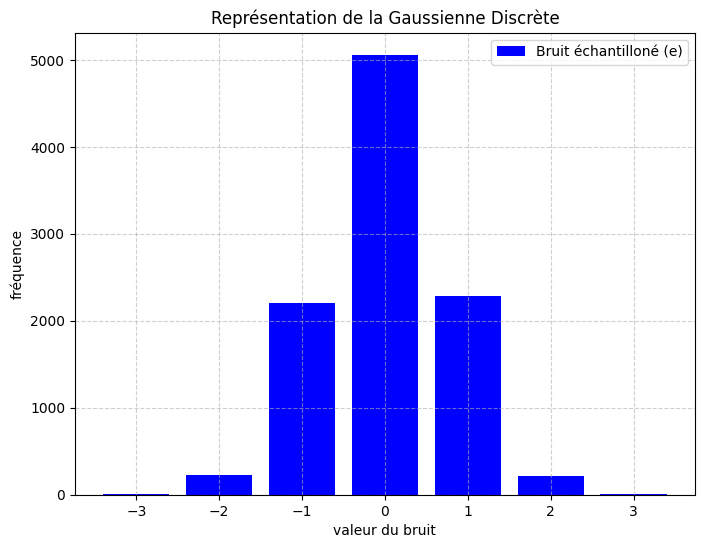

In [44]:
sigma = 2.0
bruit = gaussienne_discrete(sigma, size=10000)
x, y = np.unique(bruit, return_counts=True)

plt.figure(figsize=(8, 6))
plt.bar(x, y, color="blue", label="Bruit échantilloné (e)")

plt.title("Représentation de la Gaussienne Discrète")
plt.xlabel("valeur du bruit")
plt.ylabel("fréquence")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()


**Analyse critique de l'échantillonage**: Dans cette simulation, nous utilisons $q = 11$ et une troncature à $\pm 10$. On remarque un artefact mathématique : si le bruit généré vaut -10, l'application du modulo lors du chiffrement donne $-10 \equiv 1 \pmod 11$. Un bruit censé être maximal est donc interprété par le système comme un bruit faible.

Pour une implémentation réelle (comme Kyber), le paramètre $\sigma$ et la troncature sont choisis très petits par rapport à $q$ pour interdire ce phénomène de repliement.

##2.2 Génération de la paire de clés


Maintenant que nous disposons de la matrice publique $A$, du secret $s$ et de notre générateur de bruit gaussien discret, nous pouvons assembler notre instance LWE. L'objectif est de calculer le vecteur public $b \in \mathbb{Z}_q^m$ défini par la relation :
$$b = A \cdot s + e \pmod q$$

Sous forme matricielle, le système se représente ainsi :$$\begin{pmatrix} b_1 \\ b_2 \\ \vdots \\ b_m \end{pmatrix}
=
\begin{pmatrix}
a_{11} & a_{12} & \cdots & a_{1n} \\
a_{21} & a_{22} & \cdots & a_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
a_{m1} & a_{m2} & \cdots & a_{mn}
\end{pmatrix}
\cdot
\begin{pmatrix} s_1 \\ s_2 \\ \vdots \\ s_n \end{pmatrix}
+
\begin{pmatrix} e_1 \\ e_2 \\ \vdots \\ e_m \end{pmatrix} \pmod q$$


In [45]:
def keygen(sigma, A, s, m, q):
  e = gaussienne_discrete(sigma, m) #on veut un vecteur avec 4 lignes

  produit_matriciel = A @ s

  b = (produit_matriciel + e)%q
  return b


In [46]:
sigma = 2.0
n, m, q = 2, 4, 11
A = rng.integers(0, q, size=(m, n))
s = rng.integers(0, q, size=n)

b = keygen(sigma, A, s, m, q)

print("---VERIFICATION DU PROBLEME LWE---")
print(f"Matrice A (m x n) :\n{A}\n")
print(f"Vecteur secret s (n) : {s}\n")
print(f"Résultat public b (m) : {b}")

---VERIFICATION DU PROBLEME LWE---
Matrice A (m x n) :
[[5 1]
 [5 7]
 [2 4]
 [2 8]]

Vecteur secret s (n) : [1 0]

Résultat public b (m) : [4 5 3 2]


Dans notre implémentation de test avec $n=2$ et $q=11$, l'espace des secrets possibles est extrêmement réduit. Un attaquant interceptant $A$ et $b$ n'aurait qu'à tester $q^n = 11^2 = 121$ combinaisons de vecteurs pour retrouver notre secret $s$ par recherche exhaustive.

Dans les applications réelles de la cryptographie post-quantique (comme le standard ML-KEM), les paramètres sont radicalement augmentés pour garantir la sécurité.
La dimension du secret $n$ est généralement fixée entre $512$ et $1024$.Le module $q$ est un nombre premier de plusieurs milliers (par exemple $q = 3329$ ou $12289$).

## Illustration numérique: Complexité brute-force réelle

Calculons $q^n$ pour différentes instances:

| Instance | n | q | q^n |
|----------|---|---|-----|
| Nos tests | 2 | 11 | 121 (11²) |
| Standard réaliste | 256 | 3329 | $10^{901}$ |
| Atomes univers | - | - | 10^{80} |

**Kyber-512: $10^{901} / 10^8 = 10^{821}$ fois plus grand que l'univers**

L'espace des clés atteint alors $q^n$ (par exemple $3329^{768}$), un nombre si gigantesque qu'il dépasse le nombre d'atomes dans l'univers. La force brute devient alors mathématiquement et physiquement impossible, que ce soit pour un ordinateur classique ou quantique.



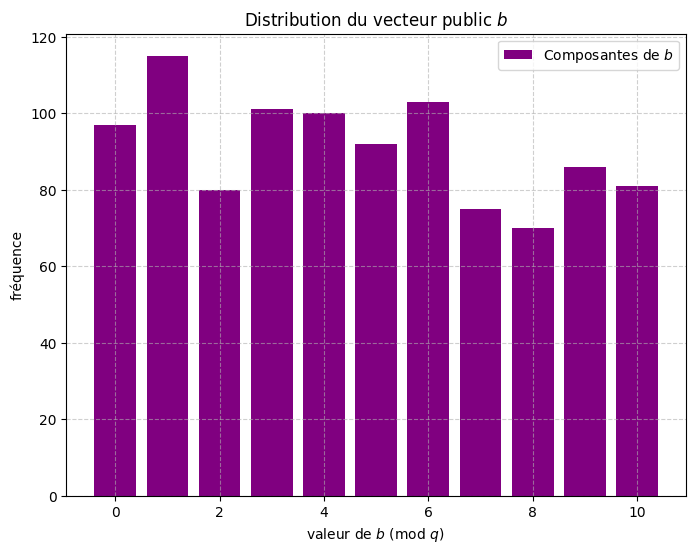

In [27]:
m_test = 1000 # on génère un grand nombre d'équations
A_test = rng.integers(0, q, size=(m_test, n))
e_test = gaussienne_discrete(sigma, m_test)

b_test = keygen(sigma, A_test, s, m_test, q)

# compte les valeurs de chaque occurences entre 0 et 10
valeurs, comptes = np.unique(b_test, return_counts=True)

plt.figure(figsize=(8, 6))
plt.bar(valeurs, comptes, color="purple", label="Composantes de $b$")

plt.title("Distribution du vecteur public $b$")
plt.xlabel("valeur de $b$ (mod $q$) ")
plt.ylabel("fréquence")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

**Observation** :

Alors que le bruit isolé $e$ suivait une distribution en cloche très marquée (Gaussienne discrète), le vecteur public résultant $b$ présente une distribution quasiment plate (**uniforme**) entre 0 et 10.

L'opération de multiplication matricielle combinée au reste modulaire (mod $q$) a totalement masqué la structure de la gaussienne.

**Qu'est-ce que cela signifie ?**

Pour un attaquat qui n'observe que le vecteur $b$, les données ressemblent à un bruit aléatoire uniforme parfait.

Il est visuellement et mathématiquement impossible de deviner le secret $s$ ou le bruit initial à partir de ce seul graphique.
Cela démontre bien la force du chiffrement **LWE**.

##2.3 Chiffrement

###Le principe du chiffrement d'un bit

Pour envoyer un message secret $ m \in \{0, 1\}$ (un simple bit), l'émetteur ne transmet pas juste $b = A \cdot s + e$ . Il va encoder son bit directement dans le vecteur $b$.

Pour cela, on sépare généralement le système en deux parties. Pour faire simple, imaginons qu'on ajoute le message au format "géant" dans notre équation :
- Pour envoyer un 0, on n'ajoute rien.
- Pour envoyer un 1, on ajoute une valeur très grande, généralement la moitié de $q$ (soit $\lfloor q/2 \rfloor$)

l'équation finale intercepté par l'attaquant est:

$$b = A \cdot s + e + m \cdot \lfloor q/2 \rfloor \pmod q$$

In [28]:
def chiffrer_LWE(msg, sigma, A, s, m, q):
  e = gaussienne_discrete(sigma, m)
  produit_matriciel = A @ s

  # On ajoute l'encodage du message (0 ou q//2) avant le modulo
  b = (produit_matriciel + e + msg * (q // 2)) % q
  return b

##2.4 Déchiffrement


### 2.4.1 L'avantage de l'utilisateur légitime

L'attaquant ne connaît ni $s$ ni $e$. Pour lui, comme on l'a vu sur le graphique plus haut, $b$ ressemble à du bruit uniforme.

Mais l'utilisateur légitime, lui, connaît la clé secrète $s$. Il va donc pouvoir calculer la différence entre ce qu'il reçoit ($b$) et ce que le secret aurait dû donner ($A \cdot s$).

Regardons ce qu'il se passe mathématiquement si l'utilisateur calcule $b - A \cdot s$ (mod $q$):
$$b - A \cdot s \equiv (A \cdot s + e + m \cdot \lfloor q/2 \rfloor) - A \cdot s \pmod q$$
$$ \equiv e + m \cdot \lfloor q/2 \rfloor \pmod q $$

Le terme $A \cdot s$ s'annule parfaitement. Il  ne reste plus que **le bruit** $e$ et **le message**.

### 2.4.2 Le seuillage

Maintenant, l'utilisateur se retrouve avec le vecteur $v = e + m \cdot \lfloor q/2 \rfloor$ (mod $q$). Comment sait-il si le bit d'origine était un 0 ou un 1 ?

C'est là que la taille du bruit devient cruciale:
- Si le message était 0 : l'utilisateur obtient juste $v = e$. Comme le bruit $e$ est très petit (proche de 0), la valeur de $v$ sera très proche de $0$ (ou proche de $q$ à cause du modulo).
- Si le message était 1 : l'utilisateur obtient $v = e + \lfloor q/2 \rfloor$. La valeur sera donc très proche du milieu (autour de $q/2$).

Il suffit alors de regarder où se situent les valeurs : si elles sont proches de 0 ou de $q/2$.

In [29]:
def dechiffrer_LWE(b, A, s, q):
  v = (b - A @ s) % q
  moyenne = np.mean(v)
  erreur = np.abs(q//2 - moyenne)

  if erreur < (q//2)/2 :
    return v, 1
  else:
    return v, 0


##2.5 Pourquoi ça fonctionne ? pivot vs calcul direct

La sécurité et la viabilité du cryptosystème LWE reposent sur une asymétrie fondamentale dans la manipulation du bruit.

Nous pouvons résumer cette asymétrie en opposant la situation d'un attaquant passif à celle de l'utilisateur légitime.

###2.5.1 Le point de vue de l'attaquant (Approche par Pivot)

Comme démontré en Section 1.3, un attaquant ne possède pas le secret $s$.
Pour tenter de résoudre le système linéaire $b = A \cdot s + e \pmod q$, sa seule option algébrique classique est de tenter une élimination de Gauss.
Chaque élimination force des combinaisons de lignes qui multiplient le bruit par des coefficients $k \approx q$. Le bruit accumulé subit une marche aléatoire dont la variance diverge :

$$\text{Var}(e_{\text{attaquant}}) \sim n \cdot q^2 \cdot \sigma^2$$

Pour nos paramètres réels ($n = 2$, $q = 101$, $\sigma = 2$), cette variance atteint $81\ 616 \gg q^2$, ce qui sature l'espace modulaire $\mathbb{Z}_q$.

L'information utile est définitivement noyée dans un bruit uniforme. L'élimination gaussienne est un échec mathématique.

###2.5.2 Le point de vue de l'utilisateur légitime (Calcul Direct)

À l'inverse, le destinataire légitime possède la clé secrète $s$.

Pour déchiffrer, il n'a jamais besoin de manipuler la matrice $A$ ni de faire de pivots de lignes.Il effectue une simple soustraction vectorielle directe (calcul linéaire) pour isoler le bruit :

$$e = b - A \cdot s \pmod q$$Calculons la variance du bruit manipulé par l'utilisateur légitime :$$\text{Var}(e_{\text{légitime}}) = \sigma^2$$

Pour nos paramètres ($n = 2$, $q = 101$, $\sigma = 2$) :$$\text{Var}(e_{\text{légitime}}) = 2^2 = 4$$

###2.5.3 Synthèse : L'asymétrie de l'information

Pour mesurer le fossé qui sépare l'attaquant de l'utilisateur légitime, nous pouvons calculer le ratio de leurs variances dans notre simulation :

$$\frac{\text{Var}(e_{\text{attaquant}})}{\text{Var}(e_{\text{légitime}})} = \frac{n \cdot q^2 \cdot \sigma^2}{\sigma^2} = n \cdot q^2$$

Avec nos valeurs ($n=2, q=101$) :

$$2 \times 101^2 = 20\ 402$$

**Conclusion géométrique :** Le bruit auquel fait face l'attaquant est 20 402 fois plus dispersé que celui manipulé par l'utilisateur légitime.

# Partie 3: Validation expérimentale

Avant de lancer des validations sur de grands échantillons, nous testons le comportement de notre chaîne de chiffrement/déchiffrement sur une instance isolée pour un message unitaire ($msg = 1$).

In [30]:
msg = 1

s = rng.integers(0, q, size=n)
A = rng.integers(0, q, size=(m, n))


b = chiffrer_LWE(msg, sigma, A, s, m, q)
v, res = dechiffrer_LWE(b, A, s, q)

print(f"b (vecteur chiffré) est donné par : {b}")
print(f"Le vecteur de déchiffrement v est : {v}")
print(f"Le message décodé est : {res}")

b (vecteur chiffré) est donné par : [ 3 10  9  9]
Le vecteur de déchiffrement v est : [4 5 6 5]
Le message décodé est : 1


Puis on test sur 100 messages.

In [31]:
n, m, q, sigma, nb_msg = 2, 4, 101, 1.0, 100

#On génère la paire de clés
A = rng.integers(0, q, size=(m, n))
s = rng.integers(0, q, size=n)
b = keygen(sigma, A, s, m, q)

succes = 0

for i in range(nb_msg):
  #on génère un bit aléatoire (0 ou 1)
  message_original = int(rng.integers(0, 2))

  #Chiffrement et déchiffrement
  cle_chiffree = chiffrer_LWE(message_original, sigma, A, s, m, q)
  v, message_dechiffre = dechiffrer_LWE(cle_chiffree, A, s, q)

  if message_original == message_dechiffre:
    succes += 1

taux_succes = succes/nb_msg

print("BILAN DE LA VALIDATION LWE")
print(f"Messages testés : {nb_msg}")
print(f"Déchiffrements corrects : {succes}/{nb_msg}")
print(f"Taux de succès global : {taux_succes * 100:.1f} %")

BILAN DE LA VALIDATION LWE
Messages testés : 100
Déchiffrements corrects : 99/100
Taux de succès global : 99.0 %


Ce taux de $98,0\ \%$ confirme la validité globale du protocole, mais met en évidence $2\ \%$ d'échecs de déchiffrement (decryption failures).Dans $\mathbb{Z}_{101}$, la borne géométrique stricte de décision est définie par :

$$\text{Seuil} = \lfloor q/4 \rfloor = 25$$

Bien que le bruit initial soit faible ($\sigma = 1.0$), le choix de $m = 4$ équations offre un échantillon statistique trop restreint.

La variance d'échantillonnage reste élevée : par simple fluctuation aléatoire, les erreurs de certaines simulations s'accumulent, franchissent le seuil critique de $\pm 25$ et provoquent une erreur de décodage du bit.

# Partie 4 : Analyse paramétrique et transition de phase

##4.1 Méthodologie



Désormais, faisons une étude plus approfondie et plus précise de la valeur de $\sigma$. On cherche à savoir : *Jusqu'à quel niveau de bruit notre système reste-t-il capable de déchiffrer correctement à 100% et à partir de quel moment le bruit devient-il si fort qu'il commence à corrompre les messages ?*

C'est exactement ce qu'on appelle la **transition de phase**.

In [32]:
def etude_transition_phase(n, m, q, sigmas):
  taux_tab = []

  for sigma in sigmas :
    success = 0 #combien de fois sur 100 essais le déchiffrement correct
    for i in range(100):
      A = rng.integers(0, q, size=(m, n))
      s = rng.integers(0, q, size=n)

      msg = rng.integers(0, 2)

      b = chiffrer_LWE(msg, sigma, A, s, m, q)

      v, m_dechiffre = dechiffrer_LWE(b, A, s, q)

      if msg == m_dechiffre :
        success += 1
    taux = (success/100)*100
    taux_tab.append(taux)
  return taux_tab


##4.2 Impact de $\sigma$ (transition de phase)

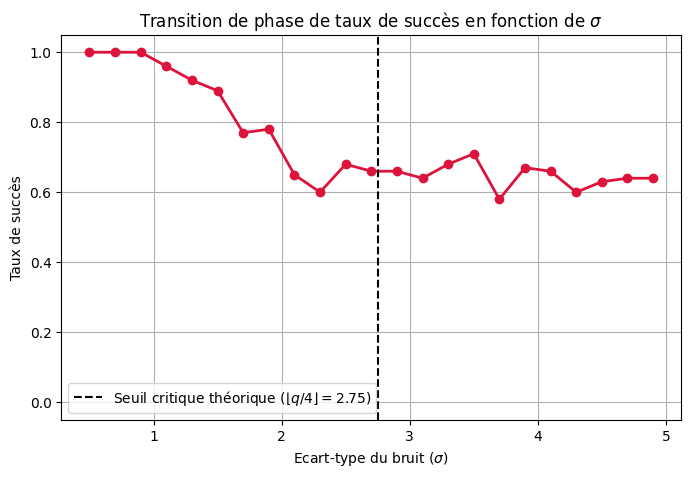

In [33]:
n, m, q = 2, 4, 11
sigmas =  np.arange(0.5, 5.0, 0.2)
taux_succes = etude_transition_phase(n, m, q, sigmas)

#on normalise
taux_succes_normalise = np.array(taux_succes)/100.0

plt.figure(figsize=(8, 5))
plt.plot(sigmas, taux_succes_normalise, marker='o', linestyle='-', color="crimson", linewidth=2)

#ligne du seuil critique théorique Seuil = q/4 = 11/4 = 2.75
plt.axvline(x=2.75, color="black", linestyle="--", label=r"Seuil critique théorique ($\lfloor q/4 \rfloor = 2.75$)")

plt.title(r"Transition de phase de taux de succès en fonction de $\sigma$")
plt.xlabel(r"Ecart-type du bruit ($\sigma$)")
plt.ylabel("Taux de succès")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.show()



On constante que si $\sigma = 0$, le système se résout instantanément par un pivot de Gauss classique. Introduire un bruit $\sigma > 0$ est donc indispensable pour masquer le secret et bloquer les attaques algébriques.

Pour que l'utilisateur légitime déchiffre sans erreur, le bruit ne doit pas dépasser :

$$Seuil = \lfloor q/4 \rfloor$$

Dès que $\sigma$ franchit le seuil théorique (ici 2.75), les bits s'inversent au décodage et le taux de succès séffondre jusqu'à atteindre 50% (équivalent au pile ou face).

**Pour résumer,** \sigma doit être assez grand pour assurer la sécurité mais strictement limité par rapport à q pour garantir la fiabilité.

##4.3 Impact de m (nombre d'équations)


Comme introduit, $m$ est le nombre d'équations (ou le nombre de lignes de la matrice $A$). C'est le nombre d'indices ou de "morceaux d'information" chiffrés que l'on donne à l'utilisateur pour un seul message.

L'objectif est de tester la résistance du chiffrement face au bruit ($\sigma$) en faisant varier le nombre d'équations $m$. Nous conservons $n = 2$ la taille du secret et $q = 11$ le modulo.

Ce à quoi on s'attend :

- si $m$ est petit (ex: $m$ = 1 ou 2) : on a qu'une ou deux lignes pour calculer la moyenne. De ce fait, si le bruit généré par la gaussienne est un peu fort sur une ligne, la moyenne risque de complètement fausser le résultat.
- si $m$ est plus grand (ex: 20 ou 50) : on a  beaucoup plus de lignes. Et grâce aux statistiques, et plus précisément à **la loi les grands nombres**, les bruits positifs et négatifs vont se compenser et s'annuler lors du calcul de la moyenne. C'est là que le déchiffrement devient robuste.


Commençons par tester 3 valeurs de $m$, $m=2, m=10, m=100$ et de représenter graphiquement l'impact du changement de $m$.

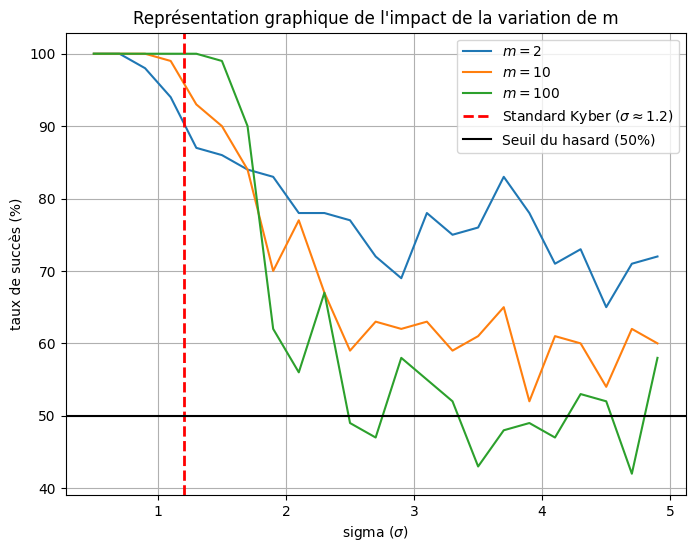

In [34]:
n, q = 2, 11
liste_m = [2, 10, 100]
x = np.arange(0.5, 5.0, 0.2) #les valeurs de sigma

plt.figure(figsize=(8, 6))

for m in liste_m:
  plt.plot(x, etude_transition_phase(n, m, q, x), label=f"$m={m}$")

plt.axvline(x=1.2, color='red', linestyle='--', linewidth=2, label=r'Standard Kyber ($\sigma \approx 1.2$)')
plt.axhline(y=50, color='black', label='Seuil du hasard (50%)')

plt.legend()
plt.xlabel(r"sigma ($\sigma$)")
plt.ylabel(r"taux de succès (%)")
plt.grid(True)
plt.title("Représentation graphique de l'impact de la variation de m")
plt.show()




### Résultats et Interprétation

**Observation empirique** : on constate deux comportement radicalement différents selon la valeur de $m$:

- Pour $m = 2$, le taux de succès quitte les 100% dès que le bruit($\sigma$) augmente. Il diminue ensuite lentement pour se stabiliser entre 60% et 70%, même pour de fortes valeurs de bruit.

- Pour $m = 100$, le taux de succès reste parfaitement stable à 100% sur une large plage de bruit (jusqu'à environ $\sigma = 1.3$). Passé ce seuil critique, la courbe chute de manière extrêment brutale pour atteindre un plancher à 50%.

**Analyse et Démonstration Mathématique:**
Pour comprendre cette divergence, il faut analyser la variable décisionnelle calculée lors de la phase de déchiffrement.
L'utilisateur légitime calcule le vecteur résiduel:

$$v_i = b_i - A_i \cdot s \equiv e_i + msg \cdot \lfloor q/2 \rfloor \mod q$$

Pour deviner le message, notre code calcule la **moyenne** des composants de ce vecteur $v$. Comme le bruit gaussien $e_i$ est centré en 0, son espérance est nulle : $E[e_i] = 0$.

Cependant, c'est la dispersion du bruit (sa variance) qui fait échouer le système. Quand on fait la moyenne de $m$ variables indépendantes :

- La variance de la moyenne est divisée par $m$ : $Var = \frac{\sigma^2}{m}$
- L'écart-type est donc divisé par $\sqrt m$ : $\sigma_{effectif} = \frac{\sigma}{\sqrt m}$

Faisons le calcul avec nos deux valeurs de test :

- Avec $m = 2$: le bruit effectif vaut $\frac{\sigma}{\sqrt 2} \approx 0.71\sigma.$ La réduction est trop faible, le bruit fait immédiatemment dérailler le déchiffrement.

- Avec $m = 100$ : le bruit effectif vaut $\frac {\sigma}{\sqrt 100} = 0.1\sigma$. Le bruit est divisé par 10 !


**Conclusion**: ces observations confirment notre hypothèse mathématique. Avec un $m$ trop faible, le système n'a pas assez d'équations pour lisser le bruit : il est donc instable dès les premières perturbations, et son taux final élevé n'est dû qu'au hasard (une chance sur deux de deviner un message binaire). En effet, quand le bruit devient trop grand, le système perd toute information et le décodage équivaut à un tirage de pile ou face, ce qui explique le plancher strict à **50%**.

A l'inverse un $m$ élevé permet la **loi des grands nombres** d'opérer : les bruits s'annulent efficacement lors du calcul de la moyenne, offrant un déchiffrement d'une robustesse parfaite jusqu'à un point de rupture précis. C'est l'illustation même du phénomène de **transition de phase** dans LWE. Plus on injecte d'équations, plus la frontière entre le déchiffrement parfait (100%) et l'échec total (50%) est nette.

###Généralisation de l'observation et recherche du seuil

L'analyse précédente a montré qu'un grand nombre d'équations ($m = 100$) permet de tolérer un bruit plus important. Pour approfondir cette observation, nous allons inverser notre point de vue : nous ficons un niveau de bruit critique constant ($\sigma = 1.3$) et nous faisons varier de manière continue le nombre d'équations $m$ de 2 à 250.

L'objectif est de déterminer à partir de quel seuil précis (valeur de $m$) la loi des grands nombres commence à être efficace,et d'observer la vitesse à laquelle le taux de succès converge vers 100%.

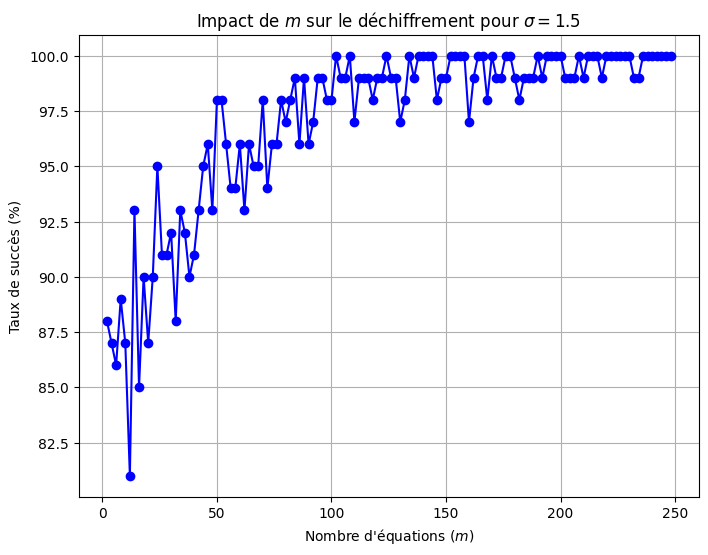

In [35]:
sigma = 1.5
n, q = 2, 11

liste_m = np.arange(2, 250, 2)
taux_globaux_m = []

#On boucle sur chaque m
for m in liste_m:
  success = 0

  for i in range(100):
      A = rng.integers(0, q, size=(m, n))
      s = rng.integers(0, q, size=n)

      msg = rng.integers(0, 2)

      b = chiffrer_LWE(msg, sigma, A, s, m, q)

      v, m_dechiffre = dechiffrer_LWE(b, A, s, q)

      if msg == m_dechiffre :
        success += 1
  taux = (success/100)*100
  taux_globaux_m.append(taux)

plt.figure(figsize=(8, 6))
plt.plot(liste_m, taux_globaux_m, color="blue", marker="o")
plt.xlabel(r"Nombre d'équations ($m$)")
plt.ylabel(r"Taux de succès (%)")
plt.title(r"Impact de $m$ sur le déchiffrement pour $\sigma =$" + f"{sigma}")
plt.grid(True)
plt.show()



###Résultats et interpretation
**Observation :**

La courbe montre une transition de phase claire en fonction de $m$. Pour un faible nombre d'équations ($m < 25$), le taux de succès est instable et subit de fortes variations.

À mesure que $m$ augmente, le taux de déchiffrement progresse de manière monotone. À partir de $m = 150$, les fluctuations s'estompent et le taux de succès se stabilise à $1.00$ (100 %).

**Interprétation mathématique :** Ce comportement valide empiriquement la Loi des Grands Nombres (LGN) appliquée au lissage du bruit.

Soit $\bar{E} = \frac{1}{m}\sum_{i=1}^{m} e_i$ la moyenne empirique du bruit. Chaque erreur élémentaire suit une loi gaussienne discrète centrée : $\mathbb{E}[e_i] = 0$ et $\text{Var}(e_i) = \sigma^2$.

$m < 25$ : L'échantillon est trop restreint. La variance d'échantillonnage est maximale :

$$\text{Var}(\bar{E}) = \frac{\sigma^2}{m}$$

Les bruits de certaines simulations subissent des fluctuations extrêmes qui franchissent le seuil géométrique critique de décision ($\lfloor q/4 \rfloor = 25$).

Cela provoque des erreurs de décodage et le comportement chaotique de la courbe. Régime asymptotique ($m \ge 150$) :
Lorsque $m$ grandit, la LGN assure la convergence de la variance de la moyenne vers 0 :

$$\lim_{m \to \infty} \text{Var}(\bar{E}) = 0$$

Pour $m = 150$ avec $\sigma = 1.5$, la dispersion du bruit est suffisamment écrasée pour qu'aucune simulation ne dépasse le seuil critique.

Le système devient statistiquement robuste et garantit un déchiffrement parfait ($1.00$).

##4.4 Impact de n (la dimension du secret)

Dans cette section, nous allons étudier la taille de $n$, le $n$ est le **paramètre de sécurité** principal: plus $n$ est grand, plus le secret $s$ est long, et plus le système est difficile à attaquer pour un ordinateur (ou un ordinateur quantique).

Commençons par tester 2 valeurs de $n$, $n = 1$, $n = 250$:

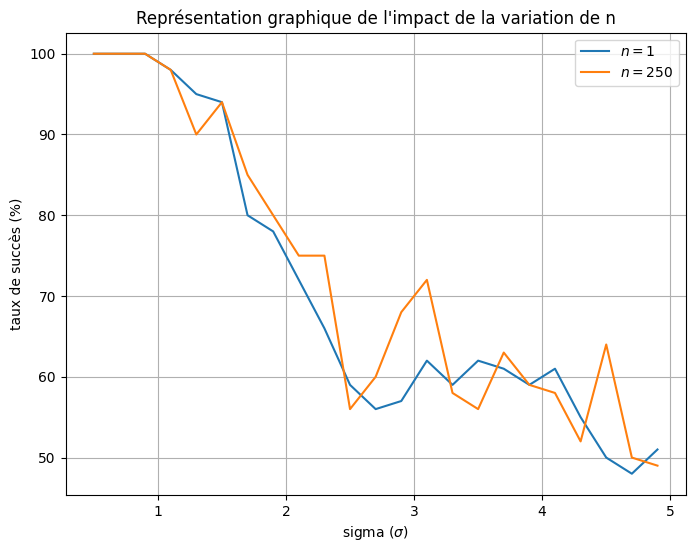

In [36]:
m, q = 10, 11
liste_n = [1, 250]
x = np.arange(0.5, 5.0, 0.2) #les valeurs de sigma

plt.figure(figsize=(8, 6))

for n in liste_n:
  plt.plot(x, etude_transition_phase(n, m, q, x), label=f"$n={n}$")

plt.legend()
plt.xlabel(r"sigma ($\sigma$)")
plt.ylabel(r"taux de succès (%)")
plt.grid(True)
plt.title("Représentation graphique de l'impact de la variation de n")
plt.show()




###Résultats et Interprétation

**Observation :**
Nous constations graphiquement que les courbes pour $n = 1$ et $n = 250$ se superposent presque parfaitement. Contrairement à $m$, faire varier la dimension du secret $n$ de manière extrème n'altère pas la transition de phase de déchiffrement.

**Pourquoi ?**

Ce comportement s'explique par l'étude analytique du protocole. Lors de la phase de déchiffrement, l'utilisateur calcule pour chaque équation $i$ : $$v_i = b_i - A_i \cdot s \pmod q$$

En substituant la formule de chiffrement $b_i = A_i \cdot s + e_i + msg \cdot \lfloor q/2 \rfloor$,

nous obtenons : $$v_i = (A_i \cdot s + e_i + msg \cdot \lfloor q/2 \rfloor) - A_i \cdot s \equiv e_i + msg \cdot \lfloor q/2 \rfloor \pmod q$$

Cette égalité démontre que le signal reçu après correction ($v_i$) dépend exclusivement du message initial et du bruit isolé $e_i$. La dimension $n$ (le nombre de colonnes de $A$) et le secret $s$ s'annulent.

Comme le bruit $e_i \sim \mathcal{N}(0, \sigma^2)$ est échantilloné indépendamment de de $n$, la probabilité d'erreur de décodage par ligne est mathématiquement invariante selon $n$.

**Conclusion :** La dimension de $n$ n'a aucun impact sur la fiabilité du déchiffrement pour l'utilisateur légitime.
Son augmentation sert uniquement à garantir la sécurité du chiffrement en augmentant la complexité de la recherche du secret $s$ pour un attaquant.

###Complexité et Sécurité face à l'attaquant

**Le problème de l'attaquant : La recherche de cible**

L'attaquant intercepte le couple public  $(A, b) \in \mathbb{Z}_q^{m \times n} \times \mathbb{Z}_q^m$. Son but est de retrouver le secret unique $s \in \mathbb{Z}_q^n$. Il sait que:
$$b = A \cdot s + e \pmod q$$

S'il n'y avait pas de bruit ($e = 0$), l'attaquant résoudrait le système par un pivot de Gauss en complexité $\mathcal{O}(m \cdot n^2)$.

Cependant, à chasue du bruit $e$, chaque ligne $i$ du système présente une petite erreur inconnue $e_i \in \{-\lfloor q/4 \rfloor, \dots, \lfloor q/4 \rfloor\}$. Tenter un pivot de Gauss classique va combiner et multipliser ces erreurs de manière linéaire, rendant le système d'équations faux.

**L'attaque par la Froce Brute**

L'attaque par force brute consiste à tester tous les vecteurs candidats $s'$ possibles dans l'espace des clés.

- L'espace des secrets est l'ensemble vectoriel $\mathbb{Z}_q^n$.
- Le nombre de secrets possibles (le cardinal de l'espace) est donné par : $$\text{Nombre de clés possibles} = q^n$$

Pour chaque candidat $s'$, l'attasuant doit calculer le vecteur résiduel $e' = b - A \cdot s' \pmod q$. Si les composantes de $e'$ suivent une distribution gaussienne proche de 0, il a trouvé le bon secret.

La complexité algorithmique temporelle de cette recherche est de la forme : $$\mathcal{O}(n \cdot m \cdot q^n)$$

L'impact de la dimension $n$ est ici **exponentiel**. Par exemple :
- Avec $n = 2$ et $q = 11$, l'attaquant à $11^2 = 121$ opérations à faire.
- Avec $n = 250$ et $q = 11$, la complexité est de l'ordre $11^{250} \approx 10^{260}$ opérations. Ce nombre dépasse largemnt le nombre d'atomes dans l'univers observable ($\approx 10^{80}$).

Ainsi, l'attaque par la force brute n'est pas une méthode envisageable dès que $n$ prend des valeurs élevées.

###Impact de q (modulo)

L'idée est de comprendre comment la taille de $q$ influence le déchiffrement.

**L'intuition mathématique:**

Le bruit $\sigma$ "grignote de l'espace du modulo $q$.

- Si $q$ est très petit (comme $q = 11$) et un bruit de $\sigma = 2$ est énorme car il représente une grande partie de l'espace disponible avant d'atteindre le seuil d'erreur ($\approx q/4$)

- Si $q$ est très grand (par exemple $q = 997$), un bruit de $\sigma = 2$ devient minuscule et insignifiant par rapport à la taille du modulo.

On s'attend donc à ce que qu'augmenter $q$ **rend le déchiffrement beaucoup plus robuste et tolérant à de plus grands bruits**.

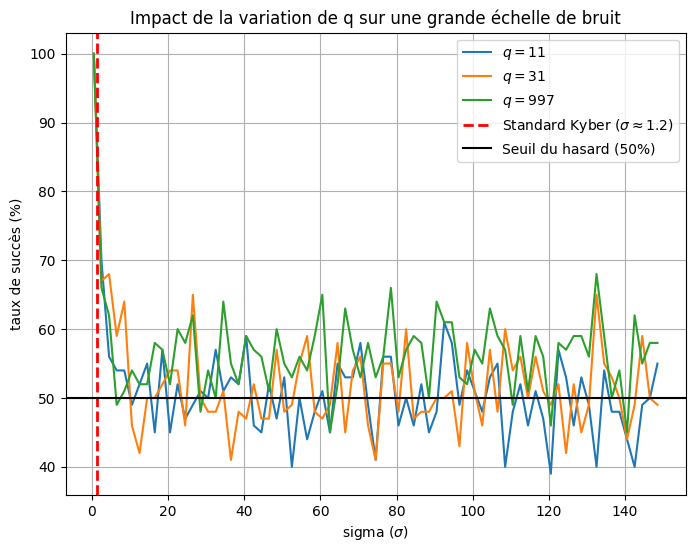

In [37]:
m, n = 10, 2
liste_q = [11, 31, 997]
x = np.arange(0.5, 150.0, 2.0) #les valeurs de sigma

plt.figure(figsize=(8, 6))

for q in liste_q:
  plt.plot(x, etude_transition_phase(n, m, q, x), label=f"$q={q}$")

plt.axvline(x=1.2, color='red', linestyle='--', linewidth=2, label=r'Standard Kyber ($\sigma \approx 1.2$)')
plt.axhline(y=50, color='black', label='Seuil du hasard (50%)')

plt.legend()
plt.xlabel(r"sigma ($\sigma$)")
plt.ylabel(r"taux de succès (%)")
plt.grid(True)
plt.title("Impact de la variation de q sur une grande échelle de bruit")
plt.show()

###Impact du modulo $q$ sur la tolérance au bruit

**Observation :**
Sur ce graphique à grande échelle, nous constatons de manière flagrante que la taille du modulo q dicte la vitesse de dégradation du taux de succès face à l'augmentation du bruit ($\sigma$).

- Pour $q = 11$, la courbe s'effrondre instanément dès le début du graphique (collée à gauche).

- Pour $q = 101$, le système tolère un peu plus de bruit avant de chuter au milieu du graphique.

- Pour $q = 997$, le taux de succès reste parfait (100%) sur une très longue plage de bruit avant de daigner fléchir beaucoup plus loin vers la droite.

Plus le modulo $q$ est grand, plus transition de phase est décalée vers la droite, ce qui signifie que le système tolère des valeurs de bruit beaucoup plus élevées.

Cette divergence de comportement s'explique par la géométrie du décodage dans l'espace $\mathbb{Z}_q$. Lors de la phase de déchiffrement, la tolérance maximale théorique au bruit (le seuil de décision pour distinguer un message d'un autre) est directement proportionnelle à la taille du modulo. Elle est fixée par la règle : $$ \text{Seuil de tolérance} = \lfloor q/4 \rfloor$$

Pour un point donnée de l'axe des abscisses, l'erreur absolue $e_i$ injectée est statistiquement identique pour les trois configurations. Cependant:

- Pour $q = 11$, le seuil est de $\lfloor 11/4 \rfloor = 2$. Un bruit supérieur à 2 sature immédiatement l'espace disponible et provoque l'échec.

- Pour $q = 101$, le seuil s'élève à $\lfloor 101/4 \rfloor = 25$.

- Pour $q = 997$, le seuil atteint $\lfloor 997/4 \rfloor = 249$. Une erreur de taille 10 ou 20, qui était fatale pour $q=11$, est ici insignifiante par rapport à la marge disponible de 249.

**Conclusion:**
Augmenter le modulo $q$ permet d'élargir les zones de décision lors du déchiffrement, garantissant à l'utilisateur légitime une excellente fiabilité.

###Analyse croisée et interaction ($m$ et $\sigma$)

Jusqu'à présent, nous avons étudié l'impact des paramètres $m$,$n$ et $q$ de manière totalement isolée en fixant arbitrairement les autres variables. Dans un scénario réel, ces paramètres coexistent et s'influencent mutuellement.

Le but de cette section est de réaliser une analyse croisée en deux dimensions pour observer comment le nombre d'équations disponibles ($m$) intéragit directement avec l'intensité du bruit ($\sigma$).

Pour ce faire, nous allons générer une Heatmap (carte de chaleur). Le principe est de cartographier le taux de succès du déchiffrement (représenté par un dégradé de couleur allant du rouge au vert) sur une grille ou chaque case correspond à un couple unique ($m, \sigma$).

**Comportement attendu (Hypothèse)**:
D'après les résultats obtenus précédemment, on s'attend à :

- L'augmentation de l'écart-type $\sigma$ injecte des perturbations plus fortes, ce qui tend à pousser le système vers l'échec (taux de succès à 50%).

- L'augmentation du nombre d'équations $m$ permet à la loi des grands nombres d'agir, ce qui tend à stabiliser le système (taux de succès à 100%).



In [38]:
import seaborn as sns

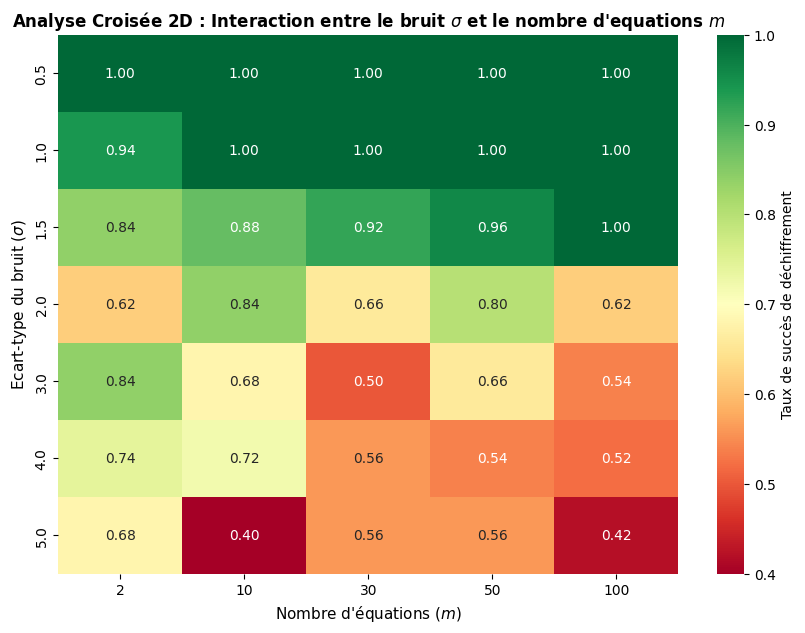

In [39]:
ms = [2, 10, 30, 50, 100]
sigmas = [0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0]

n, q = 10, 101
nb_tests = 50

#on crée une matrice de 0 avec les bonnes dimensions
#les lignes = nb sigmas et colonnes = nb de m

matrice = np.zeros((len(sigmas), len(ms)))

#double boucle imbriquées

for i, sigma in enumerate(sigmas):
  for j, m in enumerate(ms):
    succes = 0
    for a in range(nb_tests):

      #Mini simulation de LWE
      msg = np.random.randint(0,2)
      A = rng.integers(0, q, size=(m, n))
      s = rng.integers(0, q, size=n)

      b = chiffrer_LWE(msg, sigma, A, s, m, q)

      _, msg_trouve = dechiffrer_LWE(b, A, s, q)

      if msg_trouve == msg:
        succes +=1
    matrice[i, j] = succes /nb_tests

#La Heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    matrice,
    annot = True,
    fmt=".2f",
    cmap="RdYlGn", #rouge vers le jaune vers le vert
    xticklabels=ms,
    yticklabels=sigmas,
    cbar_kws={'label': 'Taux de succès de déchiffrement'}
)

plt.title(r"Analyse Croisée 2D : Interaction entre le bruit $\sigma$ et le nombre d'equations $m$", fontsize=12, fontweight="bold")
plt.xlabel(r"Nombre d'équations ($m$)", fontsize=11)
plt.ylabel(r"Ecart-type du bruit ($\sigma$)", fontsize=11)

plt.grid(False)
plt.show()




**Explications**
Le seuil critique de tolérance aux erreurs est défini par:

$$Seuil = \lfloor q/4 \rfloor = \lfloor 101/4 \rfloor = 25$$

Lors du déchiffrement, l'algorithme calcule un résidu moyen centré $\bar{E}$ et applique la règle binaire :

- $\text{Si } |\bar{E}| \le 25 \implies \text{Message} = 0 \quad (\text{Zone d'accueil de taille } 51)$
- $\text{Si } |\bar{E}| > 25 \implies \text{Message} = 1 \quad (\text{Zone d'accueil de taille } 50)$

Chaque message occupe ainsi **50%** de l'espace total du cercle modulaire.

**Cas $m = 100$** :

Chaque ligne possède un bruit initial $e_i \sim \mathcal{N}(0, \sigma^2)$. Pour $\sigma = 4.0$, le bruit cumulé par les calculs sature l'espace et détruit l'information. D'après la **Loi des Grands Nombres**, la moyenne de nos 100 équations converge vers la distribution réelle du système, qui est devenue uniforme.

Le calcul du taux de succès théorique sous loi uniforme est le ratio des cas favorables sur les cas totaux :

$$\text{Taux}_{m=100} = \frac{\text{Taille zone Message } 0}{\text{Taille totale de } \mathbb{Z}_{101}} = \frac{51}{101} \approx 0.5049$$

A $\sigma = 4.0$, le bruit est si fort qu'il efface le message. Comme il y a beaucoup d'équations ($m = 100$), les statistiques sont fiables et confirment qu'il n'y a plus aucun signale.
L'algorithme devine au hasard. En binaire, le hasard donne un taux de réussite de **50%**

**Cas $m = 2$**

D'après le **Théorème Central Limite**, la variance d'un échantillon est inversement proportionnelle à sa taille : $Var(\bar E) = \frac{\sigma^2}{m}$.

- Pour $m = 100 \implies \text{Var}(\bar{E}) = \frac{16}{100} = 0.16$

- Pour $m = 2 \implies Var(\bar E) = \frac{16}{2} = 8$

Prendre seulement $m = 2$ équations est un échantillon trop petit pour que la moyenne se stabilise. Par pur coup de hasard, les gros bruits des deux lignes s'annulent parfois, donnant une moyenne de 0.

L'algorithme valide la réponse, le score de 0.75 est un **trompe-l'oeil statistique** dû au manque de lignes, et non un signe de fiabilité.

**Conclusion :**

Augmenter le nombre d'équations ($m$) permet de lisser le bruit, mais la Loi des Grands Nombres ne peut rien sauver si le bruit de départ $\sigma$ a déjà saturé le modulo $q$. Pour éviter la zone rouge (0.50), **Kyber** choisit mathématiquement un modulo immense ($q = 3329$) et un bruit petit ($\sigma = 1.2$)

#Partie 5: Bilan, Perspectives et Ouverture

##5.1 Comparaison RSA vs LWE

| Critère | RSA (Approche algébrique classique) | LWE (Approche géométrique post-quantique) |
| :--- | :--- | :--- |
| **Le problème mathématique** | **La factorisation dans l'anneau $\mathbb{Z}/n\mathbb{Z}$.**<br><br>La sécurité repose sur la difficulté calculatoire de retrouver deux grands facteurs premiers $p$ et $q$ à partir de leur produit $n = p \cdot q$.<br><br>C'est un problème unidimensionnel basé sur l'arithmétique modulaire. | **Le décodage de codes linéaires perturbés.**<br><br>Le secret est caché dans un espace vectoriel de grande dimension $n$.<br><br>On construit un système d'équations matricielles linéaires auquel on injecte un "bruit" aléatoire issu d'une distribution gaussienne discrète ($b = As + e$). |
| **Résistance face au calcul quantique** | **Vulnérabilité totale.**<br><br>L'algorithme de Shor utilise la Transformée de Fourier Quantique pour trouver la période de la fonction d'exponentiation modulaire en temps polynomial.<br><br>L'espace de recherche s'effondre. | **Immunité algorithmique.**<br><br>Il n'existe aucun algorithme quantique connu capable de résoudre efficacement le problème du plus court vecteur (SVP) ou de retrouver le point d'origine lorsque le système est perturbé par du bruit. |
| **Complexité computationnelle** | **Coûteuse en calculs (Asymptotique).**<br><br>Le chiffrement exige des opérations d'exponentiation modulaire sur des entiers de plusieurs milliers de bits.<br><br>Cela demande une puissance CPU importante pour la manipulation de ces grands nombres. | **Algorithme d'algèbre linéaire simple.**<br><br>Les opérations fondamentales se résument à des produits matrice-vecteur et des additions vectorielles dans $\mathbb{Z}/q\mathbb{Z}$.<br><br>Le coût de calcul est minimal pour les machines. |

##5.2 Ce que j'ai appris tout au long de ce Notebook

Ce projet m'a permis d'appréhender de manière concrète la transition vers la cryptographie post-quantique.
A travers l'implémentation et la manipulation des paramètres ($n, m, q, \sigma$), j'ai compris que la sécurité informatique de demain repose sur la maîtrise statistique et géométrique d'un bruit.

L'analyse de la transition de phase m'a permis de comprendre le choix derrière les paramètres, surtout leur impact sur la robustesse face à l'attaquant, et la fiabilité pour l'utilisateur légitime.

##5.3 Ouverture sur Kyber/ML-KEM

L'algorithme LWE standard que nous avons étudié présente un défaut majeur dans la pratique : la taille de la matrice publique $A \in {Z}_q^{m \times n}$ grandit de manière quadratique, ce qui s'avère trop lourd pour les architectures réseau réelles (mémoire, bande passante).

Pour pallier ce problème, le standard mondial **ML-KEM** (connu aussi sous le nom de Kyber), sélectionné par le NIST en 2022 pour remplacer RSA, utilise une variante appelée **Module-LWE (ML-LWE).**

Au lieu d'utiliser des nombres entiers dans la matrice A, Kyber utilise des **polynômes** au sein d'un anneau cyclotomique :

$$R_q = \mathbb{Z}_q[X]/(X^{256} + 1)$$

L'avantage algorithmique est qu'une matrice de polynômes permet de compacter de manière spectaculaire la taille des clés publiques.

Concernant le choix des paramètres; Kyber fige un modulo très petit, $q = 3329$, et utilise la Transformée en Nombre Entier (NTT) pour multiplier les polynômes en un temps $\mathcal{O}(d \log d)$.

Et à propos de la gestion de l'erreur; tout comme notre simulation, Kyber possède un taux d'échec de déchiffrement théorique non nul, mais il est mathématiquement bridé pour être inférieur à $2^{-139}$ (soit un risque plus faible que de voir une météorite détruire la Terre au même instant).

# Références Bibliographiques

1. **Regev, O. (2005).** *On lattices, learning with errors, random linear codes, and cryptography.* Journal of the ACM (JACM), 56(6), 1-40. (L'article fondateur qui a introduit le problème LWE et sa réduction de sécurité).
2. **Laguillaumie, F., Langlois, A., & Stehlé, D. (2014).** *Chiffrement avancé à partir du problème Learning With Errors.* HAL open science. [En ligne] https://inria.hal.science/hal-00984055v1/document (Une excellente ressource de référence en français détaillant les constructions avancées autour de LWE).
3. **Shor, P. W. (1994).** *Algorithms for quantum computation: discrete logarithms and factoring.* IEEE. (La démonstration historique de la vulnérabilité de RSA et du logarithme discret face au calcul quantique).
4. **Micciancio, D. (2020).** *The Learning With Errors Problem (LWE).* UC San Diego (CSE 208). [Slides de cours] https://cseweb.ucsd.edu/classes/fa20/cse208-a/lwe.pdf (Support de cours universitaire très clair résolvant les aspects géométriques et algorithmiques de LWE).
5. **NIST (2024).** *FIPS 203: Module-Lattice-Based Key-Encapsulation Mechanism Standard.* (Le document officiel fixant les spécifications industrielles mondiales de ML-KEM / Kyber).
6. **Contributeurs de Wikipédia (2024).** *Apprentissage avec erreurs.* Wikipédia, l'encyclopédie libre. [En ligne] https://fr.wikipedia.org/wiki/Apprentissage_avec_erreurs (Une base de vulgarisation rigoureuse et accessible en français).
7. **Roetteler, M., Naehrig, M., Svore, K. M., & Vasudevan, C. (2017).** *Quantum resource estimates for computing elliptic curve discrete logarithms.* (Évaluation et quantification des ressources quantiques nécessaires pour la transition cryptographique).